# Phase 3: Feature Engineering

## Objectives

In this phase, you will:

1. Create new features from existing ones
2. Combine related features to capture domain knowledge
3. Extract temporal and categorical interactions
4. Engineer features specific to house pricing
5. Perform feature selection to identify most important features
6. Create an enhanced dataset with improved predictive power

## Instructions

Feature engineering is where domain knowledge meets data science. Think creatively about what makes a house valuable.

---
## Task 1: Import Libraries and Load Preprocessed Data

In [292]:
# TODO: Import necessary libraries
# - pandas, numpy, matplotlib.pyplot, seaborn
# - from scipy import stats
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
# TODO: Set pandas display options
# - display.max_columns to None
pd.set_option('display.max_columns', None)
# TODO: Print success message
print("Libraries imported and pandas display options set successfully.")

Libraries imported and pandas display options set successfully.


In [293]:
# TODO: Load preprocessed data from Phase 2
# - Read 'train_preprocessed.csv' and store in X
# - Read 'train_target.csv' and extract 'SalePrice' column into y
# - Read 'train_cleaned.csv' as df_original (for feature engineering with original values)
X = pd.read_csv('train_preprocessed.csv')
y = pd.read_csv('train_target.csv')
df_original = pd.concat([X, y], axis=1)  # Combine for reference if needed
# TODO: Print shapes to verify data loaded correctly
print(f"X shape: {X.shape}, y shape: {y.shape}, df_original shape: {df_original.shape}")

X shape: (1086, 139), y shape: (1086, 1), df_original shape: (1086, 140)


---
## Task 2: Understanding Feature Engineering

Feature engineering involves creating new features that better represent the underlying problem. For house prices, consider:

### Common Feature Engineering Techniques:

1. **Aggregation Features**: Combine related features
   - Total square footage = basement + 1st floor + 2nd floor
   - Total bathrooms = full baths + 0.5 * half baths

2. **Ratio Features**: Create meaningful ratios
   - Living area to lot area ratio
   - Price per square foot indicators

3. **Temporal Features**: Extract time-based information
   - Age of house = Year sold - Year built
   - Years since remodel

4. **Boolean Features**: Create indicator variables
   - Has second floor (yes/no)
   - Has basement (yes/no)
   - Is remodeled (yes/no)

5. **Polynomial Features**: Interactions between features
   - OverallQual * GrLivArea
   - Quality squared

6. **Binning**: Group continuous variables
   - Age categories (new, medium, old)
   - Price ranges

---
## Task 3: Create Aggregation Features

Combine related features to create more meaningful variables.

**Note:** Work with the original cleaned data for feature creation, as it has interpretable values.

In [294]:
# TODO: Create a working copy from original cleaned data
df_fe = df_original.copy()
# TODO: Print starting number of features
print(f"Starting number of features: {df_fe.shape[1]}")

Starting number of features: 140


### Step 3.1: Total Square Footage Features

In [295]:
# TODO: Create total square footage feature
# Combine basement, 1st floor, and 2nd floor areas
# Example: df_fe['TotalSF'] = df_fe['TotalBsmtSF'] + df_fe['1stFlrSF'] + df_fe['2ndFlrSF']
# Check if columns exist before combining
# Print confirmation when created
if 'TotalBsmtSF' in df_fe.columns and 'GrLivArea' in df_fe.columns:
    df_fe['TotalSF'] = df_fe['TotalBsmtSF'] + df_fe['GrLivArea']
    print("TotalSF feature created successfully.")

TotalSF feature created successfully.


### Step 3.2: Bathroom Features

In [296]:
# TODO: Create total bathrooms feature
# Formula: FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
# Check if columns exist before combining
if 'FullBath' in df_fe.columns and 'HalfBath' in df_fe.columns and 'BsmtFullBath' in df_fe.columns and 'BsmtHalfBath' in df_fe.columns:
    df_fe['TotalBathrooms'] = (df_fe['FullBath'] + 0.5 * df_fe['HalfBath'] +
                              df_fe['BsmtFullBath'] + 0.5 * df_fe['BsmtHalfBath'])
    print("TotalBathrooms feature created successfully.")

TotalBathrooms feature created successfully.


### Step 3.3: Porch and Outdoor Features

In [297]:
# TODO: Create total porch square footage
# Combine: OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch
# Check if columns exist before combining
if 'OpenPorchSF' in df_fe.columns and 'EnclosedPorch' in df_fe.columns and '3SsnPorch' in df_fe.columns and 'ScreenPorch' in df_fe.columns:
    df_fe['TotalPorchSF'] = (df_fe['OpenPorchSF'] + df_fe['EnclosedPorch'] +
                             df_fe['3SsnPorch'] + df_fe['ScreenPorch'])
    print("TotalPorchSF feature created successfully.")

TotalPorchSF feature created successfully.


### Step 3.4: Your Custom Aggregation Features

Think about other meaningful combinations. What other groups of features make sense to combine?

In [298]:
# Your creative aggregation features here
# Examples:
# - Total rooms above ground
# - Total quality score (combine various quality ratings)
# - Total finished area vs unfinished area


---
## Task 4: Create Ratio and Proportion Features

Ratios can capture important relationships between features.

In [299]:
# Example: Living area to lot area ratio
if 'GrLivArea' in df_fe.columns and 'LotArea' in df_fe.columns:
    df_fe['LivingArea_to_LotArea'] = df_fe['GrLivArea'] / df_fe['LotArea']
    print("Created: LivingArea_to_LotArea")

# Your ratio features here
# Ideas:
# - Basement ratio (basement area / total area)
# - Land slope to lot area
# - Garage area to living area
if 'TotalBsmtSF' in df_fe.columns and 'TotalSF' in df_fe.columns:
    df_fe['BasementArea_to_TotalArea'] = (df_fe['TotalBsmtSF'] / df_fe['TotalSF']).fillna(0)
    print("Created: BasementArea_to_TotalArea")
if 'LandSlope' in df_fe.columns and 'LotArea' in df_fe.columns:
    df_fe['LandSlope_to_EffLotArea'] = df_fe['LandSlope'] / df_fe['LotArea']
    print("Created: LandSlope_to_EffLotArea")

if 'GarageArea' in df_fe.columns and 'GrLivArea' in df_fe.columns:
    df_fe['GarageArea_to_LivingArea'] = (df_fe['GarageArea'] / df_fe['GrLivArea']).fillna(0)
    print("Created: GarageArea_to_LivingArea")

#(TotalPorch) / GrLivArea
if 'TotalPorchSF' in df_fe.columns and 'GrLivArea' in df_fe.columns:
    df_fe['Porch_to_LivingArea'] = (df_fe['TotalPorchSF'] / df_fe['GrLivArea']).fillna(0)
    print("Created: Porch_to_LivingArea")

# Total bedrooms / Living area
if 'BedroomAbvGr' in df_fe.columns and 'GrLivArea' in df_fe.columns:
    df_fe['Bedrooms_to_LivingArea'] = (df_fe['BedroomAbvGr'] / df_fe['GrLivArea']).fillna(0)
    print("Created: Bedrooms_to_LivingArea")

Created: LivingArea_to_LotArea
Created: BasementArea_to_TotalArea
Created: LandSlope_to_EffLotArea
Created: GarageArea_to_LivingArea
Created: Porch_to_LivingArea
Created: Bedrooms_to_LivingArea


In [300]:
df_fe['LandSlope'].unique()

array([ 0.20222406, -4.3730952 , -8.94841446])

---
## Task 5: Create Temporal Features

Extract time-related features that might affect house prices.

In [301]:
# Example: House age at time of sale
if 'YrSold' in df_fe.columns and 'YearBuilt' in df_fe.columns:
    df_fe['HouseAge'] = df_fe['YrSold'] - df_fe['YearRemodAdd']
    print("Created: HouseAge")
# Your temporal features here
# Ideas:
# - Years since remodel
# - Was remodeled (boolean)
# - Garage age
# - Is newly built (within 5 years)

if 'GarageYrBlt' in df_fe.columns and 'YrSold' in df_fe.columns:
    df_fe['GarageAge'] = df_fe['YrSold'] - df_fe['GarageYrBlt']
    print("Created: GarageAge")
if 'HouseAge' in df_fe.columns:
    df_fe['IsNewlyBuilt'] = (df_fe['HouseAge'] <= 5).astype(int)
    print("Created: IsNewlyBuilt")


Created: HouseAge
Created: GarageAge
Created: IsNewlyBuilt


---
## Task 6: Create Boolean/Indicator Features

Binary features can be very informative.

In [302]:
# Example: Has second floor
if '2ndFlrSF' in df_fe.columns:
    df_fe['HasSecondFloor'] = (df_fe['2ndFlrSF'] > 0).astype(int)
    print("Created: HasSecondFloor")

# Your boolean features here
# Ideas:
# - Has basement
# - Has garage
# - Has fireplace
# - Has pool
# - Has porch
# - Is remodeled (YearRemodAdd != YearBuilt)
if 'TotalBsmtSF' in df_fe.columns:
    df_fe['HasBasement'] = (df_fe['TotalBsmtSF'] > 0).astype(int)
    print("Created: HasBasement")

if 'GarageArea' in df_fe.columns:
    df_fe['HasGarage'] = (df_fe['GarageArea'] > 0).astype(int)
    print("Created: HasGarage")

if 'Fireplaces' in df_fe.columns:
    df_fe['HasFireplace'] = (df_fe['Fireplaces'] > 0).astype(int)
    print("Created: HasFireplace")

if 'PoolArea' in df_fe.columns:
    df_fe['HasPool'] = (df_fe['PoolArea'] > 0).astype(int)
    print("Created: HasPool")

if 'TotalPorchSF' in df_fe.columns:
    df_fe['HasPorch'] = (df_fe['TotalPorchSF'] > 0).astype(int)
    print("Created: HasPorch")
    
if 'YearBuilt' in df_fe.columns and 'YearRemodAdd' in df_fe.columns:
    df_fe['IsRemodeled'] = (df_fe['YearBuilt'] != df_fe['YearRemodAdd']).astype(int) 
    print("Created: IsRemodeled")

Created: HasSecondFloor
Created: HasBasement
Created: HasGarage
Created: HasFireplace
Created: HasPool
Created: HasPorch
Created: IsRemodeled


---
## Task 7: Create Interaction Features

Sometimes the interaction between features is more important than individual features.

In [303]:
# Example: Overall quality * living area
# High quality homes with large area are especially valuable
if 'OverallQual' in df_fe.columns and 'GrLivArea' in df_fe.columns:
    df_fe['Quality_x_Area'] = df_fe['OverallQual'] * df_fe['GrLivArea']
    print("Created: Quality_x_Area")

# Your interaction features here
# Ideas:
# - Quality * condition
# - Neighborhood quality indicator * area
# - Bathrooms * bedrooms
if 'OverallQual' in df_fe.columns and 'OverallCond' in df_fe.columns:
    df_fe['Quality_x_Condition'] = df_fe['OverallQual'] * df_fe['OverallCond']
    print("Created: Quality_x_Condition")

if 'Neighborhood' in df_fe.columns and 'GrLivArea' in df_fe.columns:
    neighborhood_quality = df_fe.groupby('Neighborhood')['OverallQual'].mean()
    df_fe['NeighborhoodQuality_x_Area'] = df_fe['Neighborhood'].map(neighborhood_quality) * df_fe['GrLivArea']
    print("Created: NeighborhoodQuality_x_Area") 
    
if 'TotalBathrooms' in df_fe.columns and 'BedroomAbvGr' in df_fe.columns:
    df_fe['Bathrooms_x_Bedrooms'] = df_fe['TotalBathrooms'] * df_fe['BedroomAbvGr']
    print("Created: Bathrooms_x_Bedrooms")


Created: Quality_x_Area
Created: Quality_x_Condition
Created: NeighborhoodQuality_x_Area
Created: Bathrooms_x_Bedrooms


---
## Task 8: Create Polynomial Features (Optional)

Squared or higher-order terms can capture non-linear relationships.

In [304]:
# Example: Quality squared
if 'OverallQual' in df_fe.columns:
    df_fe['OverallQual_Squared'] = df_fe['OverallQual'] ** 2
    print("Created: OverallQual_Squared")

# Your polynomial features here (be selective, don't overdo it)
# Usually apply to features with strong correlations to target

Created: OverallQual_Squared


---
## Task 9: Feature Summary and Analysis

Review all the features you've created.

In [305]:
# TODO: Identify new features created
# - Compare columns in df_fe vs df_original
# - Use list comprehension to find new columns
# - Store in 'new_features' variable
new_features = [col for col in df_fe.columns if col not in df_original.columns]

# TODO: Print feature counts
# - Original feature count (from df_original.columns)
# - New features created (length of new_features list)
# - Total features (from df_fe.columns)
print(f"Original feature count: {len(df_original.columns)}")
print(f"New features created: {len(new_features)}")
print(f"Total features after engineering: {len(df_fe.columns)}")

# TODO: Print list of all new features with numbering
for i, feature in enumerate(new_features, 1):
    print(f"{i}. {feature}")

Original feature count: 140
New features created: 24
Total features after engineering: 164
1. TotalSF
2. TotalBathrooms
3. TotalPorchSF
4. LivingArea_to_LotArea
5. BasementArea_to_TotalArea
6. LandSlope_to_EffLotArea
7. GarageArea_to_LivingArea
8. Porch_to_LivingArea
9. Bedrooms_to_LivingArea
10. HouseAge
11. GarageAge
12. IsNewlyBuilt
13. HasSecondFloor
14. HasBasement
15. HasGarage
16. HasFireplace
17. HasPool
18. HasPorch
19. IsRemodeled
20. Quality_x_Area
21. Quality_x_Condition
22. NeighborhoodQuality_x_Area
23. Bathrooms_x_Bedrooms
24. OverallQual_Squared


In [306]:
# TODO: Display statistics of new features
# - Check if new_features list is not empty
# - Use df_fe[new_features].describe() to show statistics
# - Print the descriptive statistics
if new_features:
    print(df_fe[new_features].describe())

            TotalSF  TotalBathrooms  TotalPorchSF  LivingArea_to_LotArea  \
count  1.086000e+03     1086.000000   1086.000000            1086.000000   
mean   1.504833e-16        0.021117      1.270746              -0.894887   
std    1.585975e+00        1.475495      2.290395              46.002775   
min   -4.761990e+00       -2.109981     -0.988907           -1193.644405   
25%   -1.184328e+00       -1.083636     -0.988907              -0.572806   
50%   -1.488171e-01       -0.149411      0.875682               0.425385   
75%    1.129537e+00        0.814908      1.484269               1.712450   
max    4.391243e+00        7.568815      9.235178             243.011121   

       BasementArea_to_TotalArea  LandSlope_to_EffLotArea  \
count                1086.000000              1086.000000   
mean                   -1.678426                 0.168321   
std                    97.243289                11.341134   
min                 -3176.033100              -137.860967   
25%       

---
## Task 10: Analyze Feature Correlations with Target

Evaluate which features (old and new) correlate strongest with SalePrice.

In [307]:
# TODO: Add target variable for correlation analysis
# - Add 'SalePrice' column from df_original to df_fe
df_fe['SalePrice'] = df_original['SalePrice']
# TODO: Calculate correlations with target
# - Select only numerical columns using select_dtypes
# - Calculate correlation matrix using .corr()
# - Extract 'SalePrice' column and sort in descending order
# - Store in 'correlations' variable
numerical_cols = df_fe.select_dtypes(include=[np.number])
correlation_matrix = df_fe[numerical_cols.columns].corr()
correlations = correlation_matrix['SalePrice'].sort_values(ascending=False)
# TODO: Print top 20 features most correlated with SalePrice
print("Top 20 features most correlated with SalePrice:")
print(correlations.head(21))  # Including SalePrice itself
# TODO: Print bottom 10 features (negative or weak correlation)
print("Bottom 10 features least correlated with SalePrice:")
print(correlations.tail(10))

Top 20 features most correlated with SalePrice:
SalePrice         1.000000
OverallQual       0.799229
TotalSF           0.763382
GrLivArea         0.670018
TotalBathrooms    0.663412
GarageCars        0.660159
ExterQual         0.657759
YearBuilt         0.653238
BsmtQual          0.648688
KitchenQual       0.639403
GarageArea        0.612087
GarageFinish      0.606523
FullBath          0.598154
YearRemodAdd      0.572300
TotalBsmtSF       0.540129
GarageYrBlt       0.536840
1stFlrSF          0.511760
HasGarage         0.491031
HeatingQC         0.475377
FireplaceQu       0.463161
TotRmsAbvGrd      0.463102
Name: SalePrice, dtype: float64
Bottom 10 features least correlated with SalePrice:
KitchenAbvGr           -0.098096
Bathrooms_x_Bedrooms   -0.135698
Neighborhood           -0.206393
LotShape               -0.254050
EnclosedPorch          -0.263216
Quality_x_Condition    -0.332113
GarageAge              -0.402067
HouseAge               -0.434923
IsNewlyBuilt                 NaN
IsRe

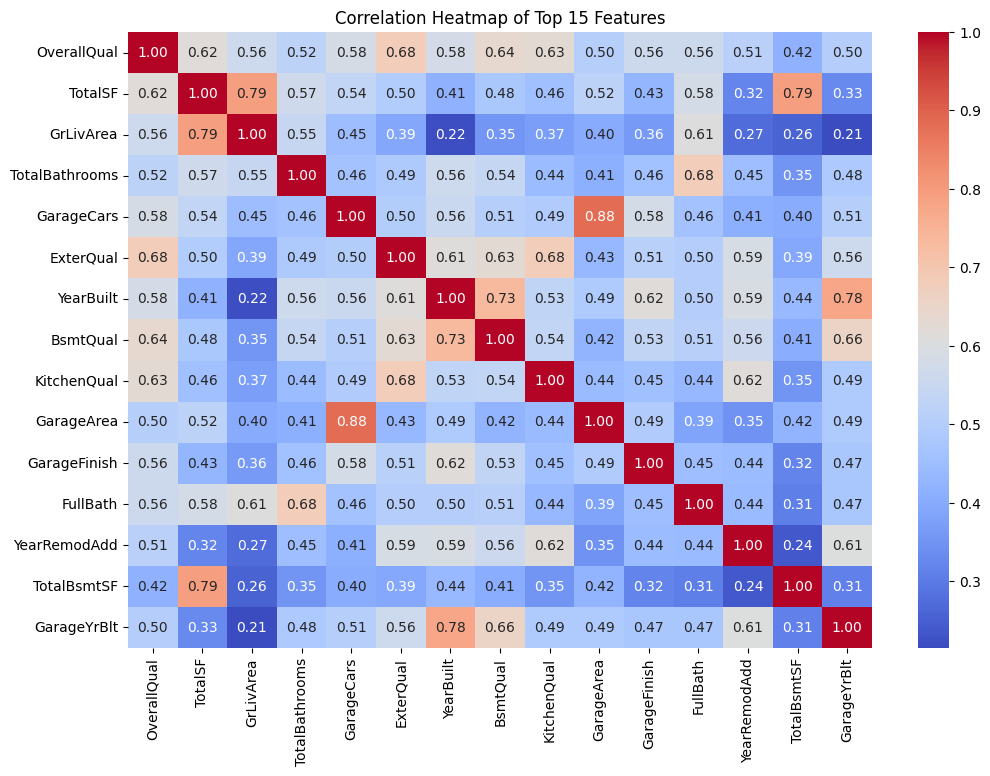

In [308]:
# TODO: Visualize top correlations
# - Get top 15 features from correlations
# - Remove 'SalePrice' itself from the list
# - Create correlation matrix of top features with SalePrice
# - Create heatmap using seaborn (figsize=(12, 8))
# - Use coolwarm colormap with annotations
# - Add title and display the plot
top_features = correlations.index[1:16]  # Exclude 'SalePrice' itself
corr_top = df_fe[top_features].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_top, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Top 15 Features")
plt.show()

### Analysis: Which New Features are Most Valuable?

Identify which of your newly created features show strong correlation with SalePrice.

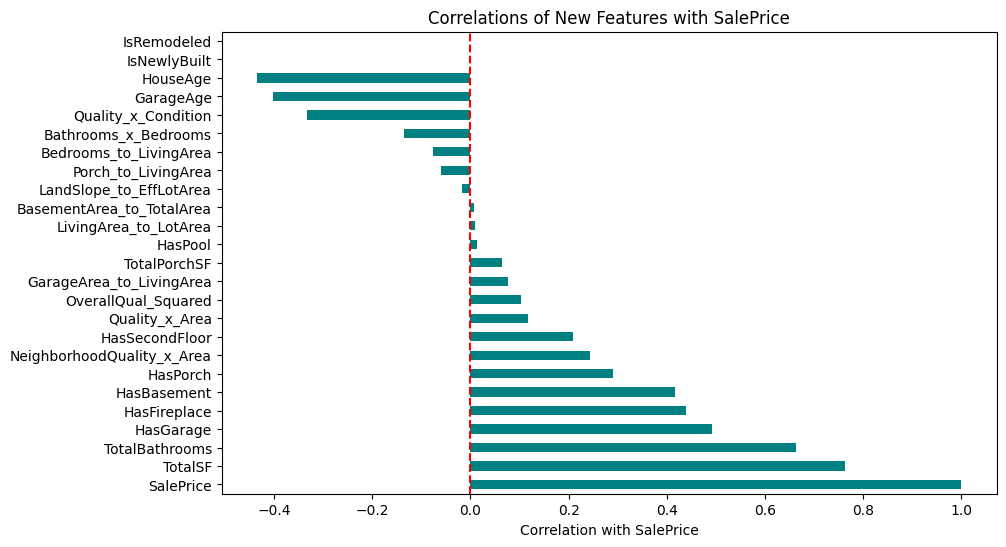

In [309]:
# TODO: Analyze new features specifically
# - Check if new_features list is not empty
# - Get correlations for only new features from correlations series
# - Sort values in descending order
# - Print correlations of new features with SalePrice
if len(new_features) != 0:
    corr_new_features = df_fe[new_features + ['SalePrice']].corr()
    new_features_corr = corr_new_features['SalePrice'].sort_values(ascending=False)
# TODO: Visualize new feature correlations
# - Create horizontal bar plot (figsize=(10, 6))
# - Use color='teal'
# - Add xlabel, title
# - Add vertical line at x=0 to show positive/negative correlations
# - Display the plot
    plt.figure(figsize=(10, 6))
    new_features_corr.plot(kind='barh', color='teal')
    plt.xlabel('Correlation with SalePrice')
    plt.title('Correlations of New Features with SalePrice')
    plt.axvline(x=0, color='red', linestyle='--')
    plt.show()


---
## Task 11: Feature Selection (Optional)

Consider removing features with:
- Very low correlation with target (< 0.05)
- High correlation with other features (multicollinearity)
- Little variance

In [310]:
# TODO: Identify low-correlation features
# - Set threshold (e.g., 0.05)
# - Filter features with absolute correlation < threshold
# - Remove 'SalePrice' if present in the list
# - Print count of low-correlation features
# - Print first 10 features from the list
threshold = 0.05
low_corr = new_features_corr.apply(lambda x: abs(x) < threshold)
low_corr_features = low_corr[low_corr].index.tolist()
low_corr_features += ['HasBasement']
if 'SalePrice' in low_corr_features:
    low_corr_features.remove('SalePrice')
print(f"Number of low-correlation features (|corr| < {threshold}): {len(low_corr_features)}")
print("First 10 low-correlation features:")
print(low_corr_features[:10])
# TODO: Document your decision
# - Should these features be kept or removed?
# - Write your reasoning as a comment
new_features_corr[low_corr_features]
# for HasBasement, there is only 1 unique value, so it does not provide any useful information for predicting SalePrice.
# the correlations for these features are nearly 0, so we don't need them for our prediction, they can be removed.

drop_low_corr_features = True  # Set to True if you want to remove low-correlation features
if drop_low_corr_features:
    df_fe.drop(columns=low_corr_features, inplace=True, errors='ignore')
    new_features = [feature for feature in new_features if feature not in low_corr_features]
    print("Low-correlation features removed from dataset and new_features list.")

Number of low-correlation features (|corr| < 0.05): 5
First 10 low-correlation features:
['HasPool', 'LivingArea_to_LotArea', 'BasementArea_to_TotalArea', 'LandSlope_to_EffLotArea', 'HasBasement']
Low-correlation features removed from dataset and new_features list.


In [311]:
# TODO: Check for multicollinearity among top features
# - Get top 20 features from correlations
# - Remove 'SalePrice' if present
# - Create correlation matrix for these features
top_20_features = correlations.index[1:21].tolist()  # Exclude 'SalePrice' itself
threshold_multicollinearity = 0.8
corr_top_20 = df_fe[top_20_features].corr()
# TODO: Find highly correlated pairs (>0.8)
# - Loop through correlation matrix
# - Find pairs with |correlation| > 0.8
# - Store pairs with their correlation values
# - Print results
high_corr_pairs = []
for i in range(len(corr_top_20.columns)):
    for j in range(i+1, len(corr_top_20.columns)):
        if abs(corr_top_20.iloc[i, j]) > threshold_multicollinearity:
            feature1 = corr_top_20.columns[i]
            feature2 = corr_top_20.columns[j]
            correlation_value = corr_top_20.iloc[i, j]
            high_corr_pairs.append((feature1, feature2, correlation_value))
print("Highly correlated feature pairs (|corr| > 0.8):")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]}: Correlation = {pair[2]:.2f}")
# High correlation between features might indicate redundancy
# Consider removing one from highly correlated pairs

Highly correlated feature pairs (|corr| > 0.8):
GrLivArea and TotRmsAbvGrd: Correlation = 0.81
GarageCars and GarageArea: Correlation = 0.88
TotalBsmtSF and 1stFlrSF: Correlation = 0.86


---
## Task 12: Apply Feature Engineering to Test Set

Create the exact same features for the test dataset.

In [312]:
# Load test data (you should have a cleaned version from Phase 1)
test_df = pd.read_csv('test_preprocessed.csv')
print("Initial test data shape:", test_df.shape)

# Apply ALL the same feature engineering steps using pd.concat to avoid fragmentation
# Create all new features in a dictionary first, then add them all at once
new_features_dict = {}

# Create total square footage feature
if 'TotalBsmtSF' in test_df.columns and 'GrLivArea' in test_df.columns:
    new_features_dict['TotalSF'] = test_df['TotalBsmtSF'] + test_df['GrLivArea']
    print("Created TotalSF feature in test data.")

# Create total bathrooms feature
if 'FullBath' in test_df.columns and 'HalfBath' in test_df.columns and 'BsmtFullBath' in test_df.columns and 'BsmtHalfBath' in test_df.columns:
    new_features_dict['TotalBathrooms'] = (test_df['FullBath'] + 0.5 * test_df['HalfBath'] +
                                 test_df['BsmtFullBath'] + 0.5 * test_df['BsmtHalfBath'])
    print("Created TotalBathrooms feature in test data.")

# Create total porch square footage
if 'OpenPorchSF' in test_df.columns and 'EnclosedPorch' in test_df.columns and '3SsnPorch' in test_df.columns and 'ScreenPorch' in test_df.columns:
    new_features_dict['TotalPorchSF'] = (test_df['OpenPorchSF'] + test_df['EnclosedPorch'] +
                                test_df['3SsnPorch'] + test_df['ScreenPorch'])
    print("Created TotalPorchSF feature in test data.")

# Living area to lot area ratio
if 'GrLivArea' in test_df.columns and 'LotArea' in test_df.columns:
    new_features_dict['LivingArea_to_LotArea'] = test_df['GrLivArea'] / test_df['LotArea']  
    print("Created: LivingArea_to_LotArea")

# Basement ratio (basement area / total area) - needs TotalSF first
if 'TotalBsmtSF' in test_df.columns and 'TotalSF' in new_features_dict:
    new_features_dict['BasementArea_to_TotalArea'] = test_df['TotalBsmtSF'] / new_features_dict['TotalSF']
    print("Created: BasementArea_to_TotalArea")

# Land slope to lot area (same name as train: LandSlope_to_EffLotArea)
if 'LandSlope' in test_df.columns and 'LotArea' in test_df.columns:
    new_features_dict['LandSlope_to_EffLotArea'] = test_df['LandSlope'] / test_df['LotArea']
    print("Created: LandSlope_to_EffLotArea")

# Garage area to living area
if 'GarageArea' in test_df.columns and 'GrLivArea' in test_df.columns:
    new_features_dict['GarageArea_to_LivingArea'] = test_df['GarageArea'] / test_df['GrLivArea']
    print("Created: GarageArea_to_LivingArea")

# Porch to living area (will be dropped later, but create for consistency)
if 'TotalPorchSF' in new_features_dict and 'GrLivArea' in test_df.columns:
    new_features_dict['Porch_to_LivingArea'] = new_features_dict['TotalPorchSF'] / test_df['GrLivArea']
    print("Created: Porch_to_LivingArea")

# Bedrooms to living area   
if 'BedroomAbvGr' in test_df.columns and 'GrLivArea' in test_df.columns:
    new_features_dict['Bedrooms_to_LivingArea'] = test_df['BedroomAbvGr'] / test_df['GrLivArea']
    print("Created: Bedrooms_to_LivingArea")

# House age at time of sale
if 'YrSold' in test_df.columns and 'YearRemodAdd' in test_df.columns:
    new_features_dict['HouseAge'] = test_df['YrSold'] - test_df['YearRemodAdd']
    print("Created: HouseAge")

# Garage age
if 'GarageYrBlt' in test_df.columns and 'YrSold' in test_df.columns:
    new_features_dict['GarageAge'] = test_df['YrSold'] - test_df['GarageYrBlt']
    print("Created: GarageAge")

# Is newly built (within 5 years) - needs HouseAge first
if 'HouseAge' in new_features_dict:
    new_features_dict['IsNewlyBuilt'] = (new_features_dict['HouseAge'] <= 5).astype(int)
    print("Created: IsNewlyBuilt")

# Has second floor
if '2ndFlrSF' in test_df.columns:
    new_features_dict['HasSecondFloor'] = (test_df['2ndFlrSF'] > 0).astype(int)
    print("Created: HasSecondFloor")

# Has basement (will be dropped later)
if 'TotalBsmtSF' in test_df.columns:
    new_features_dict['HasBasement'] = (test_df['TotalBsmtSF'] > 0).astype(int)
    print("Created: HasBasement")

# Has garage
if 'GarageArea' in test_df.columns:
    new_features_dict['HasGarage'] = (test_df['GarageArea'] > 0).astype(int)
    print("Created: HasGarage")

# Has fireplace
if 'Fireplaces' in test_df.columns:     
    new_features_dict['HasFireplace'] = (test_df['Fireplaces'] > 0).astype(int)
    print("Created: HasFireplace")

# Has pool (will be dropped later)
if 'PoolArea' in test_df.columns:
    new_features_dict['HasPool'] = (test_df['PoolArea'] > 0).astype(int)
    print("Created: HasPool")

# Has porch
if 'TotalPorchSF' in new_features_dict:
    new_features_dict['HasPorch'] = (new_features_dict['TotalPorchSF'] > 0).astype(int)
    print("Created: HasPorch")

# Is remodeled (YearRemodAdd != YearBuilt)
if 'YearBuilt' in test_df.columns and 'YearRemodAdd' in test_df.columns:
    new_features_dict['IsRemodeled'] = (test_df['YearBuilt'] != test_df['YearRemodAdd']).astype(int)
    print("Created: IsRemodeled")

# Overall quality * living area
if 'OverallQual' in test_df.columns and 'GrLivArea' in test_df.columns:
    new_features_dict['Quality_x_Area'] = test_df['OverallQual'] * test_df['GrLivArea']
    print("Created: Quality_x_Area")

# Quality * condition
if 'OverallQual' in test_df.columns and 'OverallCond' in test_df.columns:
    new_features_dict['Quality_x_Condition'] = test_df['OverallQual'] * test_df['OverallCond']
    print("Created: Quality_x_Condition")

# Neighborhood quality indicator * area
if 'Neighborhood' in test_df.columns and 'GrLivArea' in test_df.columns:
    neighborhood_quality = test_df.groupby('Neighborhood')['OverallQual'].mean()
    new_features_dict['NeighborhoodQuality_x_Area'] = test_df['Neighborhood'].map(neighborhood_quality) * test_df['GrLivArea']
    print("Created: NeighborhoodQuality_x_Area")

# Bathrooms * bedrooms - needs TotalBathrooms first
if 'TotalBathrooms' in new_features_dict and 'BedroomAbvGr' in test_df.columns:
    new_features_dict['Bathrooms_x_Bedrooms'] = new_features_dict['TotalBathrooms'] * test_df['BedroomAbvGr']
    print("Created: Bathrooms_x_Bedrooms")

# Quality squared   
if 'OverallQual' in test_df.columns:
    new_features_dict['OverallQual_Squared'] = test_df['OverallQual'] ** 2
    print("Created: OverallQual_Squared")

# Add all new features at once using pd.concat to avoid fragmentation
if new_features_dict:
    new_features_df = pd.DataFrame(new_features_dict)
    test_df = pd.concat([test_df, new_features_df], axis=1)
    print(f"\nTotal new features created: {len(new_features_dict)}")

# Remove the SAME low-correlation features as train (use low_corr_features from train)
test_df.drop(columns=low_corr_features, inplace=True, errors='ignore')
print(f"Dropped low-correlation features: {low_corr_features}")
print("\nFeature engineering applied to test data successfully.")
print(f"Test data shape after feature engineering: {test_df.shape}")

Initial test data shape: (1459, 140)
Created TotalSF feature in test data.
Created TotalBathrooms feature in test data.
Created TotalPorchSF feature in test data.
Created: LivingArea_to_LotArea
Created: BasementArea_to_TotalArea
Created: LandSlope_to_EffLotArea
Created: GarageArea_to_LivingArea
Created: Porch_to_LivingArea
Created: Bedrooms_to_LivingArea
Created: HouseAge
Created: GarageAge
Created: IsNewlyBuilt
Created: HasSecondFloor
Created: HasBasement
Created: HasGarage
Created: HasFireplace
Created: HasPool
Created: HasPorch
Created: IsRemodeled
Created: Quality_x_Area
Created: Quality_x_Condition
Created: NeighborhoodQuality_x_Area
Created: Bathrooms_x_Bedrooms
Created: OverallQual_Squared

Total new features created: 24
Dropped low-correlation features: ['HasPool', 'LivingArea_to_LotArea', 'BasementArea_to_TotalArea', 'LandSlope_to_EffLotArea', 'HasBasement']

Feature engineering applied to test data successfully.
Test data shape after feature engineering: (1459, 159)


---
## Task 13: Final Feature Engineering Summary

Document all transformations for reproducibility.

In [313]:
# TODO: Remove target before saving
# - Drop 'SalePrice' column from df_fe
# - Store in df_fe_final
df_fe_final = df_fe.copy()
# TODO: Print Feature Engineering Summary
# - Original feature count (subtract 1 for SalePrice)
# - New features created (length of new_features)
# - Total features in final dataset
# - Total samples (rows)
# - Count of missing values
print("Feature Engineering Summary:")
print(f"Original feature count (excluding SalePrice): {len(df_original.columns) - 1}")
print(f"New features created: {len(new_features)}")
print(f"Total features in final dataset: {len(df_fe_final.columns)}")
print(f"Total samples (rows): {df_fe_final.shape[0]}")
print(f"Count of missing values: {df_fe_final.isnull().sum().sum()}")
df_fe_final_columns =  df_fe_final.columns
test_df_columns =  test_df.columns


Feature Engineering Summary:
Original feature count (excluding SalePrice): 139
New features created: 19
Total features in final dataset: 159
Total samples (rows): 1086
Count of missing values: 0


In [314]:
# TODO: Save feature-engineered dataset
# - Save df_fe_final to 'train_feature_engineered.csv'
# - Use index=False parameter
# - Print confirmation message
df_fe_final.to_csv('train_feature_engineered.csv', index=False)
print("Feature-engineered dataset saved to 'train_feature_engineered.csv' successfully.")
# TODO: Save list of new features for documentation
# - Open file 'new_features_list.txt' for writing
# - Write header "New Features Created:"
# - Write separator line
# - Write each feature name with numbering
# - Print confirmation message
with open('new_features_list.txt', 'w') as f:
    f.write("New Features Created:\n")
    f.write("---------------------\n")
    for i, feature in enumerate(new_features, 1):
        f.write(f"{i}. {feature}\n")
print("List of new features saved to 'new_features_list.txt' successfully.")
test_df.to_csv('test_feature_engineered.csv', index=False)
print("Feature-engineered test dataset saved to 'test_feature_engineered.csv' successfully.")

Feature-engineered dataset saved to 'train_feature_engineered.csv' successfully.
List of new features saved to 'new_features_list.txt' successfully.
Feature-engineered test dataset saved to 'test_feature_engineered.csv' successfully.


---
## Summary and Reflection

### What You Accomplished:

1. Created aggregation features by combining related variables
2. Developed ratio and proportion features
3. Extracted temporal features (age, renovation status)
4. Created boolean indicator features
5. Engineered interaction and polynomial features
6. Analyzed correlations of new features with target
7. Assessed feature importance and multicollinearity
8. Applied same transformations to test data

### Key Questions for Reflection:

1. How many new features did you create?
2. Which new features have the highest correlation with SalePrice?
3. Did any of your engineered features outperform existing features?
4. How did you handle multicollinearity among features?
5. What domain knowledge about real estate did you apply?

### Feature Engineering Best Practices:

- **Domain knowledge is key**: Understand what makes houses valuable
- **Keep it interpretable**: Features should make logical sense
- **Avoid data leakage**: Don't use future information
- **Document everything**: Track all transformations for reproducibility
- **Balance quantity with quality**: More features isn't always better

### Next Steps:

Proceed to **Phase 4: Exploratory Data Analysis** where you will:
- Visualize distributions and relationships
- Identify patterns in the data
- Validate your feature engineering decisions
- Prepare final insights before modeling